# **Offer Recommender System for Telecom Products/Services**


## **Introduction**

Offer recommendation in the telecom industry refers to the process of **suggesting personalized offers** to customers based on their usage patterns, demographics, and other relevant factors. Offering recommendations in the telecom industry is crucial for improving customer satisfaction and increasing revenue. By using advanced algorithms and big data techniques, telecom companies can provide customers with relevant and valuable offers, leading to higher customer loyalty and long-term growth.

### **Business Impact of Offer Recommendation**

**Increase customer satisfaction**: Offer recommendation allows telecom companies to understand their customers better and provide them with relevant and valuable offers, leading to higher customer satisfaction.


**Increase revenue**: By providing customers with relevant and valuable offers, telecom companies can increase their revenue through increased customer spending and reduced churn.


**Improve customer loyalty**: By providing personalized offers to customers, telecom companies can create a better customer experience and build stronger relationships with their customers, leading to higher customer loyalty.


## **Possible solutions**


There are various ways to build an offer recommendation system, and the choice depends on factors such as the data available, the complexity of the system, and the computational resources available. Some approaches are:


### **1. Rule-based systems:**
 In this approach, offers are recommended based on predefined rules. Rule-based systems are easy to implement and interpret, but they may not be very accurate or adaptive. It makes sense to use them when you have a specific business mandate (example - we want to use product A to promote product B because of a Marketing Strategy so we will recommend product B to everyone who bot A).


### **2. Collaborative filtering:**
 Collaborative filtering is a type of recommendation that recommends offers based on the preferences of similar customers. In this approach, we find what customers are similar among themselves and similar offers to similar customers.


### **3. Content-based filtering:**
In this approach, the system builds a model of the customer's preferences based on the features of the offers they have interacted with and then recommends offers that are similar in terms of those features. Content-based filtering is useful when the system has access to rich feature data, but it can struggle with the cold start problem (i.e., recommending new offers to customers who have not interacted with any offers yet). This is the type of thing that powers retailers' recommendations - they get similar products to what you bought and recommend it to you.


### **4. Hybrid systems:**
Hybrid systems combine different approaches to leverage their strengths and mitigate their weaknesses. For example, a system might use a collaborative filtering approach to recommend offers to customers who have already interacted with offers, and a content-based approach to recommend offers to new customers.




## **Approach**


We are treating this problem as an unsupervised learning problem. This means that, in practice, we don't have a way in this dataset to validate if what we did is 'right' or 'wrong'.


In real life, the approach here would be to test this algorithm with real customers to see if this improves churn.


Given our assumptions about the offers, we will build a collaborative-filtering system based on the user. Simplifying, here's the logic of what we'll build:


1. We'll build an algorithm to identify who identifies, for customer A, who are the n-most similar customers;
2. We'll use a churn-rate approach to identify, among the similar customers, what is the most successful offer;
3. We will then choose the most successful offer to provide to our customer A.


We'll be training this algorithm on part of the dataset of customers who have received the offer (have A,B,C,D,E,F,G,H,I or J) in their 'offer' field. The idea is to apply that to the 'No Offer' group. 



## **Learning Outcomes**


* How to load data from AWS SQL using pyodbc and pandas
* Exploratory Data Analysis
* Categorical Feature Encoding using Labelencoder
* Data Preprocessing and Feature Engineering
* Understanding Cosine Similarity, Manhattan distance, Euclidean distance
* How to choose a distance metric for a specific problem?
* What is the minimum threshold parameter?
* Build a user based collaborative offer recommendation system
* Bootstrapping the offer recommendation system
* Testing of the algorithm in production


## **Package Requirements**

In [1]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances

## **The data**

### **AWS S3 - CSV**
Use the S3 public link to read the CSV file directly into a pandas DataFrame


### **The database**

In [2]:
# use s3_link if you are connected with internet
s3_link='https://s3.amazonaws.com/projex.dezyre.com/recommender-system-for-telecom-products/materials/Telecom_data.csv'
df = pd.read_csv(s3_link)

## if not use following and provide the path accordingly
# csv_file_path='../data/Telecom_data.csv'
# df = pd.read_csv(csv_file_path)

In [3]:
df.head(5)

,Customer ID,Month,Month of Joining,zip_code,Gender,Age,Married,Dependents,Number of Dependents,Location ID,...,Streaming Movies,Streaming Music,Unlimited Data,Payment Method,Status ID,Satisfaction Score,Churn Category,Churn Reason,Customer Status,Churn Value
0,hthjctifkiudi0,1,1,71638,Female,36.000000,No,No,0.0,jeavwsrtakgq0,...,Yes,Yes,Yes,Credit Card,vvhwtmkbxtvsppd52013,3,Competitor,Competitor offered higher download speeds,Churned,1
1,uqdtniwvxqzeu1,6,6,72566,Male,36.472065,No,No,0.0,qcvetdmalnkw1,...,No,No,No,Bank Withdrawal,jucxaluihiluj82863,4,Not Applicable,Not Applicable,Stayed,0
2,uqdtniwvxqzeu1,7,6,72566,Male,36.442687,No,No,0.0,qcvetdmalnkw1,...,No,No,Yes,Credit Card,vjskkxphumfai57182,3,Not Applicable,Not Applicable,Stayed,0
3,uqdtniwvxqzeu1,8,6,72566,Male,36.837888,No,No,0.0,qcvetdmalnkw1,...,No,No,Yes,Wallet Balance,cdwbcrvylqca53109,4,Not Applicable,Not Applicable,Stayed,0
4,uqdtniwvxqzeu1,9,6,72566,Male,36.490214,No,No,0.0,qcvetdmalnkw1,...,Yes,No,Yes,Credit Card,whqrmeulitfj98550,1,Not Applicable,Not Applicable,Stayed,0


In [4]:
print(df.shape)
print(df.columns)

(653753, 74)
Index(['Customer ID', 'Month', 'Month of Joining', 'zip_code', 'Gender', 'Age',
       'Married', 'Dependents', 'Number of Dependents', 'Location ID',
       'Service ID', 'state', 'county', 'timezone', 'area_codes', 'country',
       'latitude', 'longitude', 'roam_ic', 'roam_og', 'loc_og_t2t',
       'loc_og_t2m', 'loc_og_t2f', 'loc_og_t2c', 'std_og_t2t', 'std_og_t2m',
       'std_og_t2f', 'std_og_t2c', 'isd_og', 'spl_og', 'og_others',
       'loc_ic_t2t', 'loc_ic_t2m', 'loc_ic_t2f', 'std_ic_t2t', 'std_ic_t2m',
       'std_ic_t2f', 'std_ic_t2o', 'spl_ic', 'isd_ic', 'ic_others',
       'total_rech_amt', 'total_rech_data', 'vol_4g', 'vol_5g', 'arpu_5g',
       'arpu_4g', 'arpu', 'night_pck_user', 'fb_user', 'aug_vbc_5g', 'offer',
       'Referred a Friend', 'Number of Referrals', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Streaming Data Consumption', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tec

When we inspect the dataframe, we notice the same customer appears more than once, in different months.

We have 2 options here:
1. Create a consolidated frame where each customer is in 1 line;
2. Use the different moments in time of each customer as a datapoint;

The latter approach gives us more data points in theory, because in different months customers could have behaved differently. We will follow with approach number 2. However, we need to keep this in mind as we calculate similarity scores.

## **Exploratory Data Analysis**

### **Data Dictionary**



| Column name	 | Description|
| ----- | ----- |
| Customer ID	 | Unique identifier for each customer |
| Month | Calendar Month- 1:12 | 
| Month of Joining |	Calender Month -1:14, Month for which the data is captured|
| zip_code |	Zip Code|
|Gender |	Gender|
| Age |	Age(Years)|
| Married |	Marital Status |
|Dependents | Dependents - Binary |
| Number of Dependents |	Number of Dependents|
|Location ID |	Location ID|
|Service ID	 |Service ID|
|state|	State|
|county	|County|
|timezone	|Timezone|
|area_codes|	Area Code|
|country	|Country|
|latitude|	Latitude|
|longitude	|Longitude|
|arpu|	Average revenue per user|
|roam_ic	|Roaming incoming calls in minutes|
|roam_og	|Roaming outgoing calls in minutes|
|loc_og_t2t|	Local outgoing calls within same network in minutes|
|loc_og_t2m	|Local outgoing calls outside network in minutes(outside same + partner network)|
|loc_og_t2f|	Local outgoing calls with Partner network in minutes|
|loc_og_t2c	|Local outgoing calls with Call Center in minutes|
|std_og_t2t|	STD outgoing calls within same network in minutes|
|std_og_t2m|	STD outgoing calls outside network in minutes(outside same + partner network)|
|std_og_t2f|	STD outgoing calls with Partner network in minutes|
|std_og_t2c	|STD outgoing calls with Call Center in minutes|
|isd_og|	ISD Outgoing calls|
|spl_og	|Special Outgoing calls|
|og_others|	Other Outgoing Calls|
|loc_ic_t2t|	Local incoming calls within same network in minutes|
|loc_ic_t2m|	Local incoming calls outside network in minutes(outside same + partner network)|
|loc_ic_t2f	|Local incoming calls with Partner network in minutes|
|std_ic_t2t	|STD incoming calls within same network in minutes|
|std_ic_t2m	|STD incoming calls outside network in minutes(outside same + partner network)|
|std_ic_t2f|	STD incoming calls with Partner network in minutes|
|std_ic_t2o|	STD incoming calls operators other networks in minutes|
|spl_ic|	Special Incoming calls in minutes|
|isd_ic|	ISD Incoming calls in minutes|
|ic_others|	Other Incoming Calls|
|total_rech_amt|	Total Recharge Amount in Local Currency|
|total_rech_data|	Total Recharge Amount for Data in Local Currency
|vol_4g|	4G Internet Used in GB|
|vol_5g|	5G Internet used in GB|
|arpu_5g|	Average revenue per user over 5G network|
|arpu_4g|	Average revenue per user over 4G network|
|night_pck_user|	Is Night Pack User(Specific Scheme)|
|fb_user|	Social Networking scheme|
|aug_vbc_5g|	Volume Based cost for 5G network (outside the scheme paid based on extra usage)|
|offer|	Offer Given to User|
|Referred a Friend|	Referred a Friend : Binary|
|Number of Referrals|	Number of Referrals|
|Phone Service|	Phone Service: Binary|
|Multiple Lines|	Multiple Lines for phone service: Binary|
|Internet Service|	Internet Service: Binary|
|Internet Type|	Internet Type|
|Streaming Data Consumption|	Streaming Data Consumption|
|Online Security|	Online Security|
|Online Backup|	Online Backup|
|Device Protection Plan|	Device Protection Plan|
|Premium Tech Support|	Premium Tech Support|
|Streaming TV|	Streaming TV|
|Streaming Movies|	Streaming Movies|
|Streaming Music|	Streaming Music|
|Unlimited Data|	Unlimited Data|
|Payment Method|	Payment Method|
|Status ID|	Status ID|
|Satisfaction Score|	Satisfaction Score|
|Churn Category|	Churn Category|
|Churn Reason|	Churn Reason|
|Customer Status|	Customer Status|
|Churn Value|	Binary Churn Value



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653753 entries, 0 to 653752
Data columns (total 74 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Customer ID                 653753 non-null  object 
 1   Month                       653753 non-null  int64  
 2   Month of Joining            653753 non-null  int64  
 3   zip_code                    653753 non-null  int64  
 4   Gender                      653753 non-null  object 
 5   Age                         653753 non-null  float64
 6   Married                     653753 non-null  object 
 7   Dependents                  653753 non-null  object 
 8   Number of Dependents        653753 non-null  float64
 9   Location ID                 653753 non-null  object 
 10  Service ID                  653753 non-null  object 
 11  state                       653753 non-null  object 
 12  county                      653753 non-null  object 
 13  timezone      

In [6]:
df['offer'].unique() # how many unique offers are there

array(['A', 'F', 'No Offer', 'J', 'E', 'C', 'I', 'B', 'D', 'H', 'G'],
      dtype=object)

In [7]:
# Taking a look at the offer distribution
dfg = df.groupby('offer').agg({'Customer ID':'count'}).reset_index()
dfg['% Total'] = dfg['Customer ID']/dfg['Customer ID'].sum() #this creates a % of total column
dfg['% Total'] = dfg['% Total'].apply(lambda x: '{:.2%}'.format(x)) #this function simply formats the column to %
dfg #this displays the dataframe

,offer,Customer ID,% Total
0,A,15915,2.43%
1,B,15871,2.43%
2,C,16153,2.47%
3,D,16162,2.47%
4,E,15833,2.42%
5,F,15789,2.42%
6,G,15778,2.41%
7,H,15855,2.43%
8,I,15860,2.43%
9,J,15893,2.43%


**Observation**
* The Offers seems to be evenly distributed amongst customers
* There are about 76% users who did not receive any offer from the company


In [8]:
# Taking a look at the offer distribution and churn distribution
dfg2 = df.groupby(['offer','Customer Status']).agg({'Customer ID':'count'}).reset_index()
pivoted_dfg2 = dfg2.pivot(index='offer', columns='Customer Status', values='Customer ID')
pivoted_dfg2 = pivoted_dfg2.reset_index()
pivoted_dfg2['Churn Rate'] = pivoted_dfg2['Churned']/(pivoted_dfg2['Churned'] + pivoted_dfg2['Stayed'])
pivoted_dfg2['Churn Rate'] = pivoted_dfg2['Churn Rate'].apply(lambda x: '{:.2%}'.format(x)) #this function simply formats the column to %
pivoted_dfg2

Customer Status,offer,Churned,Stayed,Churn Rate
0,A,1464,14451,9.20%
1,B,1441,14430,9.08%
2,C,1470,14683,9.10%
3,D,1484,14678,9.18%
4,E,1418,14415,8.96%
5,F,1459,14330,9.24%
6,G,1409,14369,8.93%
7,H,1477,14378,9.32%
8,I,1468,14392,9.26%
9,J,1483,14410,9.33%


**Observations**

* churn rate seems to be similar amongst customers regardless of the offer they received -> this tells us that maybe offers are not being tailored enough to groups


In [9]:
# Taking a look at the churn category
dfg2 = df.groupby(['Churn Category',]).agg({'Customer ID':'count'}).reset_index()
dfg2['% Total'] = dfg2['Customer ID']/dfg2['Customer ID'].sum() #this creates a % of total column
dfg2['% Total'] = dfg2['% Total'].apply(lambda x: '{:.2%}'.format(x)) #this function simply formats the column to %
dfg2 #this displays the dataframe

,Churn Category,Customer ID,% Total
0,Attitude,296,0.05%
1,Competitor,5974,0.91%
2,Dissatisfaction,6001,0.92%
3,Not Applicable,622748,95.26%
4,Other,4356,0.67%
5,Price,4381,0.67%
6,Support,7538,1.15%
7,Unknown,1269,0.19%
8,bcvjhdjcb,1190,0.18%


**Observations**

* The Churn Category for Competitor, Dissatisfaction, Price, Support have higher customers
* We can give them specific offers which may lead them to stay rather than churning


## **Data Processing**

### **Missing Value Detection and Imputation**

In [10]:
percent_missing = df.isna().sum() * 100 / len(df)
print(percent_missing[percent_missing > 0])

total_rech_data    32.107539
night_pck_user     57.070943
fb_user            62.775085
Multiple Lines      7.048534
Internet Type      49.751206
Unlimited Data      1.698348
dtype: float64


In [11]:
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing.values})
missing_value_df.sort_values(by='percent_missing',ascending=False)

,column_name,percent_missing
49,fb_user,62.775085
48,night_pck_user,57.070943
57,Internet Type,49.751206
42,total_rech_data,32.107539
55,Multiple Lines,7.048534
...,...,...
24,std_og_t2t,0.000000
23,loc_og_t2c,0.000000
22,loc_og_t2f,0.000000
21,loc_og_t2m,0.000000


**Observation**

*  Columns 'fb_user' and 'night_pck_user' have more 50% missing value. We will simply **drop** this from our dataframe
* According to data dictionary 'Internet Type' and 'total_rech_data' seems to correlated.
* We need to check for columns 'Internet Type' and 'total_rech_data' and **impute missing values if possible**


In [12]:
df=df.drop(columns=['fb_user','night_pck_user'])

In [13]:
df['total_rech_data'].isna().sum()

209904

In [14]:
df['Internet Type'].isna().sum()

325250

**Observation:**

*  These missing values may represent customers who have not recharged their account or have recharged but the information has not been recorded.

* It is possible that customers with missing recharge data are those who received free data service, and therefore did not need to recharge their account. Alternatively, it is possible that the missing values are due to technical issues, such as data recording errors or system failures.

In [15]:
# Checking the value counts of Internet Service where total recharge data was null
df[df['total_rech_data'].isna()]['Internet Service'].value_counts(dropna=False)

Internet Service
Yes    209904
Name: count, dtype: int64

In [16]:
df[(df['total_rech_data'].isna())]['Unlimited Data'].value_counts()

Unlimited Data
Yes    181040
No      28864
Name: count, dtype: int64

In [17]:
df[(df['total_rech_data'].isna())][['arpu_4g','arpu_5g']].value_counts()

arpu_4g         arpu_5g       
Not Applicable  Not Applicable    195182
297.57          8530.983629            4
544.17          8536.565906            3
395.94          8533.210427            3
290.09          8530.814304            3
                                   ...  
222.42          1468.94                1
222.56          8529.28563             1
222.67          8529.28812             1
222.73          8529.289478            1
2559.56         8582.188229            1
Name: count, Length: 14247, dtype: int64

**Observation**:

* We can fill the missing values in the total_rech_data column with 0 when the arpu (Average Revenue Per User) is not applicable. This is because the arpu is a measure of the revenue generated per user, and if it is not applicable, it may indicate that the user is not generating any revenue for the company. In such cases, it is reasonable to assume that the total data recharge amount is 0
* It is advisable to check with the business before making this decision 

In [18]:
# Replacing all values of total recharge data= 0 where arpu 4g and 5g are not applicable
df.loc[(df['arpu_4g']=='Not Applicable') | (df['arpu_5g']=='Not Applicable'),'total_rech_data']=0
# Missing value percentage after imputation
df['total_rech_data'].isna().sum()/df.shape[0]

0.022519208324856637

In [19]:
# Calculate the mean of 'total_rech_data' where either 'arpu_4g' or 'arpu_5g' is not equal to 'Not Applicable'
arpu_data_mean=df.loc[(df['arpu_4g']!='Not Applicable') | (df['arpu_5g']!='Not Applicable'),'total_rech_data'].mean()
arpu_data_mean

4.85274721808543

In [20]:
# Fill NaN values in 'total_rech_data' with the mean of 'total_rech_data' where either 'arpu_4g' or 'arpu_5g' is not equal to 'Not Applicable'
df['total_rech_data']=df['total_rech_data'].fillna(arpu_data_mean)
df['total_rech_data'].isna().sum()

0

In [21]:
# Check the value counts for Internet Type
df['Internet Type'].value_counts(dropna=False)

Internet Type
NaN            325250
Fiber Optic    134991
Cable          112100
DSL             81412
Name: count, dtype: int64

In [22]:
# Check value counts for Internet Service where Internet Type is null
df[df['Internet Type'].isna()]['Internet Service'].value_counts(dropna=False)

Internet Service
No     236152
Yes     89098
Name: count, dtype: int64

In [23]:
# Filling Null values in Internet Type 
df['Internet Type']=df['Internet Type'].fillna('Not Applicable')

In [24]:
# Replace 'Not Applicable' with 0 in 'arpu_4g'
df['arpu_4g'] = df['arpu_4g'].replace('Not Applicable', 0)

# Replace 'Not Applicable' with 0 in 'arpu_5g'
df['arpu_5g'] = df['arpu_5g'].replace('Not Applicable', 0)

# Convert 'arpu_4g' to float data type
df['arpu_4g'] = df['arpu_4g'].astype(float)

# Convert 'arpu_5g' to float data type
df['arpu_5g'] = df['arpu_5g'].astype(float)

### **Outlier Detection and Imputation**


In [25]:
# List of continuous columns
cts_cols=['Age','Number of Dependents',
       'roam_ic', 'roam_og', 'loc_og_t2t',
       'loc_og_t2m', 'loc_og_t2f', 'loc_og_t2c', 'std_og_t2t', 'std_og_t2m',
       'std_og_t2f', 'std_og_t2c', 'isd_og', 'spl_og', 'og_others',
       'loc_ic_t2t', 'loc_ic_t2m', 'loc_ic_t2f', 'std_ic_t2t', 'std_ic_t2m',
       'std_ic_t2f', 'std_ic_t2o', 'spl_ic', 'isd_ic', 'ic_others',
       'total_rech_amt', 'total_rech_data', 'vol_4g', 'vol_5g', 'arpu_5g',
       'arpu_4g', 'arpu', 'aug_vbc_5g', 'Number of Referrals','Satisfaction Score',
       'Streaming Data Consumption']   

# Create an empty dataframe with columns as cts_cols and index as quantiles
quantile_df=pd.DataFrame(columns=cts_cols,index=[0.1,0.25,0.5,0.75,0.8,0.9,0.95,0.97,0.99])

# for each column in cts_cols, calculate the corresponding quantiles and store them in the quantile_df
for col in cts_cols:
   quantile_df[col]=df[col].quantile([0.1,0.25,0.5,0.75,0.8,0.9,0.95,0.97,0.99])
quantile_df

,Age,Number of Dependents,roam_ic,roam_og,loc_og_t2t,loc_og_t2m,loc_og_t2f,loc_og_t2c,std_og_t2t,std_og_t2m,...,total_rech_data,vol_4g,vol_5g,arpu_5g,arpu_4g,arpu,aug_vbc_5g,Number of Referrals,Satisfaction Score,Streaming Data Consumption
0.10,24.0,0.0,0.000000,0.000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0000,0.0000,0.000000,0.000000,-256.2000,0.0000,0.0,1.0,0.0
0.25,28.0,0.0,12.090000,14.710,32.7000,26.260000,1.460000,1.610000,33.120000,25.560000,...,0.000000,0.0000,0.0000,0.000000,0.000000,118.9400,0.0000,0.0,3.0,2.0
0.50,34.0,0.0,50.560000,75.100,171.3300,135.460000,7.800000,8.180000,174.600000,134.800000,...,0.000000,47.0100,362.3800,0.000000,0.000000,348.5400,117.3200,4.0,3.0,20.0
0.75,43.0,1.0,162.030000,135.280,309.0900,618.210000,14.090000,14.700000,316.240000,244.490000,...,2.000000,154.9000,964.7200,194.470000,228.220000,580.6500,311.7500,8.0,4.0,49.0
0.80,47.0,2.0,496.902000,146.820,856.7660,1392.937844,43.870000,15.970000,344.970000,266.540000,...,4.852747,176.3600,3814.2220,789.000000,783.290000,626.2300,350.4900,8.0,4.0,56.0
0.90,55.0,4.0,969.043806,689.598,3613.9960,2644.568000,126.593474,109.097149,1547.136000,1007.842370,...,14.000000,219.2680,12369.5160,2219.752000,2224.100000,1901.5140,789.0000,10.0,5.0,69.0
0.95,61.0,7.0,1283.198000,1954.392,5079.8300,3479.438000,183.490000,207.514000,3953.108671,3108.617986,...,23.000000,663.2040,17358.4180,8530.865147,8675.302558,5892.6180,3943.2100,11.0,5.0,77.0
0.97,64.0,8.0,1494.043200,2550.390,5806.0544,3756.444400,206.750000,277.344400,5344.123200,3848.301590,...,26.000000,1438.5100,19569.9704,8724.440600,8839.721689,7592.5688,5949.3792,11.0,5.0,80.0
0.99,74.0,9.0,1646.899600,3041.760,6191.2040,4060.298800,257.650000,311.464800,6729.403200,4875.216400,...,30.000000,4289.8496,254687.0000,254687.000000,254687.000000,8846.9584,7366.7684,11.0,5.0,83.0


**Observation**

The variables vol_5g, arpu_4g, and arpu_5g seems to have some abrupt values

In [26]:
# Checking further
df['arpu_4g'].quantile([0.75,0.8,0.9,0.95,0.97,0.99,0.999])

0.750       228.220000
0.800       783.290000
0.900      2224.100000
0.950      8675.302558
0.970      8839.721689
0.990    254687.000000
0.999    254687.000000
Name: arpu_4g, dtype: float64

In [27]:
# Calculate the proportion of rows in the DataFrame where the value in the 'arpu_4g' column is equal to 254687
df[df['arpu_4g']==254687].shape[0]/df.shape[0]

0.019651152652454366

In [28]:
# Get the value counts of 'total_rech_data' for observations where the value in the 'arpu_4g' column is equal to 254687
df[df['arpu_4g']==254687]['total_rech_data'].value_counts()

total_rech_data
0.0    12847
Name: count, dtype: int64

Now, since the recharge amount is 0 and there is no ARPU, let's replace it with 0.

In [29]:
# Replace the outlier value 254687 in the 'arpu_4g' column of the dataframe 'df' with 0.
df['arpu_4g']=df['arpu_4g'].replace(254687,0)

In [30]:
# Checking further
df['arpu_4g'].quantile([0.75,0.8,0.9,0.95,0.97,0.99,0.999])

0.750      120.570000
0.800      504.112000
0.900     1893.758000
0.950     2493.880000
0.970     8675.470757
0.990     8839.721689
0.999    87978.000000
Name: arpu_4g, dtype: float64

In [31]:
# Filter by 'arpu_4g' value of 87978 and count unique values in 'total_rech_data' column
df[df['arpu_4g']==87978]['total_rech_data'].value_counts()

total_rech_data
0.0    5007
Name: count, dtype: int64

All rows in the dataframe with an 'arpu_4g' value of 87978 have 0 value in the 'total_rech_data' column, indicating that these are likely outliers. Therefore, we have decided to replace the 'arpu_4g' value for these rows with 0.

In [32]:
# Replace the values with 0
df['arpu_4g']=df['arpu_4g'].replace(87978,0)

In [33]:
# Checking the quantiles again
df['arpu_4g'].quantile([0.75,0.8,0.9,0.95,0.97,0.99,0.999])

0.750     107.760000
0.800     432.246000
0.900    1803.560000
0.950    2424.072000
0.970    2735.554400
0.990    8705.097343
0.999    8839.721689
Name: arpu_4g, dtype: float64

This seems to be fairly good now

In [34]:
# Get the value counts of 'total_rech_data' for observations where the value in the 'arpu_5g' column is equal to 254687
df[df['arpu_5g']==254687]['total_rech_data'].value_counts()

total_rech_data
0.0    12614
Name: count, dtype: int64

In [35]:
# Get the value counts of 'total_rech_data' for observations where the value in the 'arpu_5g' column is equal to 87978
df[df['arpu_5g']==87978]['total_rech_data'].value_counts()

total_rech_data
0.0    5130
Name: count, dtype: int64

In [36]:
# Replacing the values with 0 where total recharge data is 0
df['arpu_5g']=df['arpu_5g'].replace([87978,254687],0)

In [37]:
# Check the quantiles of ARPU 5G
df['arpu_5g'].quantile([0.75,0.8,0.9,0.95,0.97,0.99,0.999])

0.750      96.490000
0.800     417.102000
0.900    1797.618000
0.950    2543.904000
0.970    2792.060000
0.990    8587.153966
0.999    8724.440600
Name: arpu_5g, dtype: float64

This seems to be fairly good now

In [38]:
# Replace the outlier values
df['vol_5g']=df['vol_5g'].replace([87978,254687],0)

In [39]:
# Check the quantiles of Volume of 5G data
df['vol_5g'].quantile([0.75,0.8,0.9,0.95,0.97,0.98,0.99,0.999])

0.750      895.8100
0.800     1654.5460
0.900     9658.3760
0.950    14517.6400
0.970    16580.3764
0.980    17551.8796
0.990    18614.5528
0.999    19746.1824
Name: vol_5g, dtype: float64

Lets store this processed data for further use.

In [40]:
df_processed = df.copy()
#df.to_csv('processed_telecom_offer_data.csv',index=False)

## **Feature engineering**

**1. Splitting the dataset into a training and production dataset:**

- Training: part of the customers who received offers which will be used to train the model
- Production: customers who did not received offers to whom we'd like to then offer something

In [41]:
# Let's split our dataframe in a training and production dataset:
def split_dataframe(data):
    train = data[data['offer']!='No Offer']
    production = data[data['offer']=='No Offer']
    return train, production

In [42]:
train, production = split_dataframe(df_processed)

In [43]:
train.shape,production.shape

((159109, 72), (494644, 72))

Here we are not dealing with traditional train test split method as we are building an unsupervised collaborative recommender system.
Now to make model learn we need to pass all the data with respect to offers.


we are creating 2 dataframes for each train and production, that have the Customer ID as a join key. This will help us manipulate features, and also trace them back to a particular customer;


In [44]:
#This help us identify the customer and the business outcomes
id_variables = ['Customer ID', 'Month','Month of Joining','offer','Churn Category',
       'Churn Reason', 'Customer Status', 'Churn Value']


#This helps us identify the different profiles of customers
selected_variables = ['Customer ID', 'Month', 'Month of Joining', 'Gender', 'Age',
                      'Married', 'Number of Dependents', 'area_codes','roam_ic', 'roam_og',
                      'loc_og_t2t','loc_og_t2m', 'loc_og_t2f', 'loc_og_t2c', 'std_og_t2t', 'std_og_t2m',
                      'std_og_t2f', 'std_og_t2c', 'isd_og', 'spl_og', 'og_others',
                      'loc_ic_t2t', 'loc_ic_t2m', 'loc_ic_t2f', 'std_ic_t2t', 'std_ic_t2m',
                      'std_ic_t2f', 'std_ic_t2o', 'spl_ic', 'isd_ic', 'ic_others',
                      'total_rech_amt', 'total_rech_data', 'vol_4g', 'vol_5g', 'arpu_5g',
                      'arpu_4g', 'arpu', 'aug_vbc_5g','Number of Referrals', 'Phone Service',
                      'Multiple Lines', 'Internet Service', 'Internet Type',
                      'Streaming Data Consumption', 'Online Security', 'Online Backup',
                      'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
                      'Streaming Movies', 'Streaming Music', 'Unlimited Data',
                      'Payment Method']

train_id=train[id_variables]
train_feat=train[selected_variables]

prod_id=production[id_variables]
prod_feat=production[selected_variables]

In the code above, what we have essentially eliminated are complex variables like latitude, longitude and timezone because they could be represented by the area_codes variable, that represents location.

**2. Converting the Month of Joining into a customer tenure**

In [45]:
train_feat['tenure'] = train_feat['Month']- train_feat['Month of Joining']
train_feat['tenure'].describe()
prod_feat['tenure'] = prod_feat['Month']- prod_feat['Month of Joining']
prod_feat['tenure'].describe()

/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/3941133429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_feat['tenure'] = train_feat['Month']- train_feat['Month of Joining']
/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/3941133429.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prod_feat['tenure'] = prod_feat['Month']- prod_feat['Month of Joining']


count    494644.000000
mean          3.830003
std           3.018754
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max          13.000000
Name: tenure, dtype: float64

**3.Transforming Categorical Variables**

**Note:** We are NOT using dummies here to minimize the explosion of columns because of the distance methods we are using.

In [46]:
# Now we need to transform the features of the feature store.
def encode_categorical_features(train_df,prod_df):
    # Get a list of all categorical columns
    cat_columns = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Encode each categorical column
    for col in cat_columns:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col])
        prod_df[col]= le.transform(prod_df[col])
    return train_df, prod_df

In [47]:
#excluding the customer ID so it doesn't get encoded
train_label_data=train_feat[train_feat.columns.difference(['Customer ID','Month','Month of Joining'])]
prod_label_data=prod_feat[prod_feat.columns.difference(['Customer ID','Month','Month of Joining'])]
train_feat_enc, prod_feat_enc = encode_categorical_features(train_label_data,prod_label_data)

/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/1391466617.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[col] = le.fit_transform(train_df[col])
/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/1391466617.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prod_df[col]= le.transform(prod_df[col])
/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/1391466617.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [48]:
##bringing back the customer ids keys
train_feat_enc['Customer ID'] = train_feat['Customer ID'] #bringing back the customer id
train_feat_enc['Month'] = train_feat['Month'] #bringing back the Month
train_feat_enc['Month of Joining'] = train_feat['Month of Joining'] #bringing back the Month of joining

prod_feat_enc['Customer ID'] = prod_feat['Customer ID'] #bringing back the customer id
prod_feat_enc['Month'] = prod_feat['Month'] #bringing back the Month
prod_feat_enc['Month of Joining'] = prod_feat['Month of Joining'] #bringing back the Month of joining


/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/289144358.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_feat_enc['Customer ID'] = train_feat['Customer ID'] #bringing back the customer id
/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/289144358.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_feat_enc['Month'] = train_feat['Month'] #bringing back the Month
/var/folders/dy/p7g7n6253j76sj1k7y99nbv80000gn/T/ipykernel_71335/289144358.py:6: SettingWithCopyWa

**4. Taking a look at the final list of variables**


In [49]:
train_feat_enc.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,159109.0,36.634975,12.179496,19.000000,28.00,34.00,43.000000,80.000000
Device Protection Plan,159109.0,0.498514,0.499999,0.000000,0.00,0.00,1.000000,1.000000
Gender,159109.0,0.782690,0.842949,0.000000,0.00,1.00,1.000000,3.000000
Internet Service,159109.0,0.609670,0.487826,0.000000,0.00,1.00,1.000000,1.000000
Internet Type,159109.0,2.031400,1.142408,0.000000,1.00,2.00,3.000000,3.000000
Married,159109.0,1.005041,0.921703,0.000000,0.00,1.00,2.000000,2.000000
Multiple Lines,159109.0,0.577089,0.621380,0.000000,0.00,1.00,1.000000,2.000000
Number of Dependents,159109.0,1.162522,2.248864,0.000000,0.00,0.00,1.000000,9.000000
Number of Referrals,159109.0,4.338764,3.768069,0.000000,0.00,4.00,8.000000,11.000000
Online Backup,159109.0,0.331169,0.470635,0.000000,0.00,0.00,1.000000,1.000000


In [50]:
train = pd.merge(train_feat_enc,train_id[['Customer ID','Month','Month of Joining','Churn Value','offer']],how = 'inner',on=['Customer ID','Month','Month of Joining'])
production = pd.merge(prod_feat_enc,prod_id[['Customer ID','Month','Month of Joining','Churn Value','offer']],how = 'inner',on=['Customer ID','Month','Month of Joining'])

In [51]:
## This help us check if we did not duplicate anything in the columns

print(len(train))
print(len(production))

159109
494644


## **Model Building and Testing**

In [52]:
def get_recommended_offers (df:pd.DataFrame, df_id:pd.DataFrame,customer_id:str,month:int,distance_func:str,n,minimal_threshold:float,max_offers_to_return:int):
    """
    This function takes as parameters:
    1. the dataframe where we'll be getting our data
    2. the customer identifiers Customer Id and the Month we want to make an offer for
    3. the distance function we want to use to calculate similaries between customers (see explanation below on how to chose it)
    4. The number of other customers we want to base our recommendations on
    5. The minimal threshold of prevalence of a given offer, in the similar group of customers, for it to be considered for recommendation (see explanation below on how to chose it)
    
    It returns:
    An array with the list of offers that we could recommend to this customer
    """

    # extract the feature vectors of all customers
    features = list(df.columns.difference(['Customer ID','Month','Month of Joining','offer']))
    X = df[features].values

    # extract the feature vector of the given customer
    index = df[(df['Customer ID'] == customer_id) & (df['Month']==month)].index[0]
    x = X[index]

    # compute the distances between the feature vectors
    if distance_func == 'euclidean':
      distances = euclidean_distances(X, x.reshape(1, -1)).flatten()
    elif distance_func == 'manhattan':
      distances = manhattan_distances(X, x.reshape(1, -1)).flatten()
    elif distance_func == 'cosine':
      distances = 1 - cosine_similarity(X, x.reshape(1, -1)).flatten()
    else:
      raise ValueError('Invalid distance function specified.')

    # find the indices of the n customers with lowest distance
    most_similar_indices = distances.argsort()[:n]
            
    # extract the customer data for the most similar customers
    similar_customers = df.iloc[most_similar_indices]

    # merge with the id dataframe to select only the customers who did not churn
    similar_customers = pd.merge(similar_customers,df_id[['Customer ID','Month of Joining','Month','Churn Value']],on=['Customer ID','Month of Joining','Month','Churn Value'])

    # select the customers that did not churn
    similar_customers = similar_customers[similar_customers['Churn Value']==0]

    #count the top offers of the non-churned customers
    top_offers = similar_customers[['Customer ID','offer']].groupby(['offer']).agg({'Customer ID':'count'}).reset_index().sort_values(by = 'Customer ID', ascending = False)
    top_offers['perc_total'] = top_offers['Customer ID']/top_offers['Customer ID'].sum()
    top_offers_min = top_offers[top_offers['perc_total']>minimal_threshold].head(max_offers_to_return)
        
    return top_offers_min['offer'].unique()

### **Function Overview**

This function finds n similar customers with respect to the distance metric provided by user from training data corresponding to specific customer. 

It further finds the most occurring offers given to set of n similar customers and recommend the top 3 offers.


**Input Parameters :**
1. df: The main DataFrame that contains all the data for all customers and their offers

2. df_id: A DataFrame that contains only the customer ID, month of joining, and churn value and offer

3. customer_id: The ID of the customer we want to recommend offers for

4. month: The month we want to make the offer for

5. distance_func: The distance function to use for finding similar customers

6. n: The number of other customers we want to base our recommendations on

7. minimal_threshold: The minimal threshold of prevalence of a given offer in the similar group of customers, for it to be considered for recommendation

8. max_offers_to_return: The maximum number of offers to return



#### **Step by Step Explanation**

* Extracts the feature vectors of all customers by removing the 'Customer ID', 'Month', 'Month of Joining', and 'offer' columns from the main DataFrame

```
features = list(df.columns.difference(['Customer ID','Month','Month of Joining','offer']))
X = df[features].values
```

* Extracts the feature vector of the given customer

```
index = df[(df['Customer ID'] == customer_id) & (df['Month']==month)].index[0]
x = X[index]
```

* Computes the distances between the feature vectors of the given customer and all other customers using the specified distance function

```
if distance_func == 'euclidean':
    distances = euclidean_distances(X, x.reshape(1, -1)).flatten()
elif distance_func == 'manhattan':
    distances = manhattan_distances(X, x.reshape(1, -1)).flatten()
elif distance_func == 'cosine':
     distances = 1 - cosine_similarity(X, x.reshape(1, -1)).flatten()
else:
    raise ValueError('Invalid distance function specified.')
```

* Finds the indices of the n customers with the lowest distance to the given customer

```
most_similar_indices = distances.argsort()[:n]
```

* Extracts the customer data for the most similar customers

```
similar_customers = df.iloc[most_similar_indices]
```

* Merges the similar customers DataFrame with the ID DataFrame to select only the customers who did not churn

```
similar_customers = pd.merge(similar_customers,df_id[['Customer ID','Month of Joining','Month','Churn Value']],on=['Customer ID','Month of Joining','Month','Churn Value'])
```

* Selects the customers that did not churn

```
similar_customers = similar_customers[similar_customers['Churn Value']==0]
```

* Counts the top offers of the non-churned customers, calculates the percentage of each offer among the top offers, and selects the top max_offers_to_return offers whose percentage is above the minimal_threshold

```
top_offers = similar_customers[['Customer ID','offer']].groupby(['offer']).agg({'Customer ID':'count'}).reset_index().sort_values(by = 'Customer ID', ascending = False)
top_offers['perc_total'] = top_offers['Customer ID']/top_offers['Customer ID'].sum()
top_offers_min = top_offers[top_offers['perc_total']>minimal_threshold].head
```

### **Applying this framework to a specific customer**

In [53]:
train[train['Customer ID']=='sirifvlkipkel21']

,Age,Device Protection Plan,Gender,Internet Service,Internet Type,Married,Multiple Lines,Number of Dependents,Number of Referrals,Online Backup,...,tenure,total_rech_amt,total_rech_data,vol_4g,vol_5g,Customer ID,Month,Month of Joining,Churn Value,offer
24,40.0,0,0,1,0,2,0,0.0,10.0,0,...,1,452,3.0,12.04,127.5,sirifvlkipkel21,12,11,0,G


In [54]:
customer_id = 'sirifvlkipkel21' # This Customer Id needs to be there from the training dataset
month = 12
distance_func = 'euclidean'
n = 1000
minimal_threshold= 0.10
max_offers_to_return = 3

id_cols=['Customer ID','Month','Month of Joining','Churn Value','offer']

offers = get_recommended_offers (train, train[id_cols], customer_id,month,distance_func,n,minimal_threshold,max_offers_to_return)

print('The first offer to recommend is ' + str(offers[0]))
print('The second offer to recommend is ' + str(offers[1]))
print('The third offer to recommend is ' + str(offers[2]))

The first offer to recommend is C
The second offer to recommend is G
The third offer to recommend is F


Instead of adding this result to a list, we could also add it to a dataframe:

In [55]:
frame = pd.DataFrame()

data = {'Customer ID': [customer_id],
        'Month': [month],
        'offer 1': [str(offers[0])],
        'offer 2': [str(offers[1])],
        'offer 3': [str(offers[2])]}

frame= pd.DataFrame(data)
frame.head(2)

,Customer ID,Month,offer 1,offer 2,offer 3
0,sirifvlkipkel21,12,C,G,F


This essentially tells us for the particular customer id we can recommend C, G, F offers respectively in month 12.


## **Bootstrapping the framework**


Especially in unsupervised learning problems, it is always a good idea to run several approaches (`bootstrap`) and chose the most common answer amongst the different models. This mechanism is similar to what algorithms like random forest do, for example: they fit several trees and each tree votes the final classification of a sample.

We are going to play with the **3 distances** we have in our function + the **number of customers** we pull the data from in order to get a voted answer

In [58]:
def find_similar_customers_multiple(df:pd.DataFrame, df_id:pd.DataFrame,customer_id:str,month:int,distance_funcs:list,n_values,minimal_threshold:float,max_offers_to_return:int):
    """
    Given a dataframe, a customer_id, n values, and distance functions,
    run multiple iterations of the find_similar_customers function with different parameter combinations,
    and return the top 3 most common answers among those.
    """
    results = []
    for n in n_values:
      for distance_func in distance_funcs:
          result = get_recommended_offers (df,df_id ,customer_id,month,distance_func,n,minimal_threshold,max_offers_to_return)
          results.append(result)
          # concatenate the arrays together
          concatenated_array = np.concatenate(results)
          # convert the concatenated array to a Python list
          result_list = list(concatenated_array)
          result_list
    if len(results) == 0:
        return None
    else:
        result_counts = pd.Series(result_list).value_counts()
        most_common_result = [result_counts.index[0],result_counts.index[1],result_counts.index[2]]
        return most_common_result

**Function Overview**

This function takes a **dataframe**, a **customer ID**, a **month**, a **list of distance functions**, a **list of n values**, a **minimal threshold**, and a **max number of offers** to return as input parameters. It uses these parameters to **run multiple iterations** of the get_recommended_offers function and returns the top 3 most common recommendations among them.

First, the function initializes an empty results list to store the results of each iteration. Then, for each n value and distance function, it calls the get_recommended_offers function with the given parameters and appends the result to the results list. After all iterations are completed, the function concatenates the arrays together and converts them to a Python list.

If the results list is empty, meaning no recommendations were generated, the function returns None. Otherwise, it uses the value_counts() function to count the frequency of each recommended offer in the result_list, and returns a list of the top 3 most common recommendations.

### **Applying this framework to a given customer** 

In [59]:
n_values = [100, 250, 500, 1000]
distance_funcs = ['euclidean', 'manhattan', 'cosine']
customer_id = 'sirifvlkipkel21'
month = 12
minimal_threshold= 0.10
max_offers_to_return = 3
id_cols=['Customer ID','Month','Month of Joining','Churn Value','offer']
find_similar_customers_multiple(train, train[id_cols],customer_id,month,distance_funcs,n_values,minimal_threshold=0.10,max_offers_to_return=3)

['G', 'A', 'I']

### **Seeing how this function work in details**

In [60]:
# parameter values
n_values = [100, 250, 500, 1000]
distance_funcs = ['euclidean', 'manhattan', 'cosine']
customer_id = 'sirifvlkipkel21'
month = 12
minimal_threshold= 0.10
max_offers_to_return = 3
results = []


In [61]:
# for each value in n_values 
# The number of other customers we want to base our recommendations on
for n in n_values:
  # chose distance metric from a list
  for distance_func in distance_funcs:
    
      # get the offer recommendation by using get_recommended_offers function
      result = get_recommended_offers (train, train[id_cols],customer_id,month,distance_func,n,minimal_threshold,max_offers_to_return)
      
      results.append(result)
      # concatenate the arrays together
      concatenated_array = np.concatenate(results)
      # convert the concatenated array to a Python list
      result_list = list(concatenated_array)
if len(results) == 0:
    None
else:
    result_counts = pd.Series(result_list).value_counts()
    most_common_result = [result_counts.index[0],result_counts.index[1],result_counts.index[2]]
    most_common_result
result_counts

G    10
A     7
I     5
C     5
J     4
D     3
F     2
Name: count, dtype: int64

We can see above that the different iterations returned **7 potential offers**.   
3 of those were, however, much more common than 6 of the rest.

In [62]:
most_common_result

['G', 'A', 'I']

The most_common_result list will aggregate the top 3 offers

### **Applying this to the whole dataframe**

#### **For the function without bootstrapping**

In [63]:
train_id.columns

Index(['Customer ID', 'Month', 'Month of Joining', 'offer', 'Churn Category',
       'Churn Reason', 'Customer Status', 'Churn Value'],
      dtype='object')

In [67]:
def production_model(df, train, production, distance_func, n):
    frame = pd.DataFrame()
    # Pour chaque client dans chaque mois
    for customer in list(df['Customer ID'].unique()):
        for month in list(df[df['Customer ID'] == customer]['Month'].unique()):
            # Cette partie du code ajoute la ligne que nous voulons obtenir des offres à l'ensemble d'entraînement
            data = pd.concat([train, production[(production['Customer ID'] == customer) & (production['Month'] == month)]])
            data = data.reset_index(drop=True)
            data_id = data[['Customer ID', 'Month', 'Month of Joining', 'Churn Value']]
            results = get_recommended_offers(data, data_id, customer, month, distance_func, n, minimal_threshold=0.10, max_offers_to_return=3)
            data = {'Customer ID': [customer],
                    'Month': [month],
                    'offers': [results]}
            frame1 = pd.DataFrame(data)
            frame = pd.concat([frame, frame1], ignore_index=True)
    return frame

**Function Overview**

The production_model function takes in a dataframe df, a distance function distance_func, and a value n, and returns a new dataframe frame with recommended offer in each month.

For each unique Customer ID and Month combination in the input dataframe, the function adds the line for that combination to a new dataframe data that includes all previous training data plus the current combination. The get_recommended_offers function is then called on this new data dataframe, using the given distance_func and n values, to obtain a list of recommended offers for that combination.

A dictionary is then created to store the Customer ID, Month, and offers data, and a new dataframe frame1 is created from this dictionary. This new dataframe is then appended to the existing frame dataframe.

Finally, the frame dataframe is returned, which contains the recommended offers for each unique Customer ID and Month combination in the input dataframe.

In [68]:
frame_production_100_samples = production_model (production.head(100),train=train,production=production,distance_func = 'euclidean',n = 250)
frame_production_100_samples.to_csv('offer_recommendation_without_bootstap.csv',index=False)

#### **For the function with bootstrapping**

In [71]:
def production_model_bootstrap(df, train, production, distance_funcs, n_values):
    frame = pd.DataFrame()
    for customer in list(df['Customer ID'].unique()):
        for month in list(df[df['Customer ID'] == customer]['Month'].unique()):
            # Cette partie du code ajoute la ligne que nous voulons obtenir des offres à l'ensemble d'entraînement
            data = pd.concat([train, production[(production['Customer ID'] == customer) & (production['Month'] == month)]])
            data = data.reset_index(drop=True)
            data_id = data[['Customer ID', 'Month', 'Month of Joining', 'Churn Value']]
            results = find_similar_customers_multiple(
                data, data_id, customer, month, distance_funcs=distance_funcs, n_values=n_values,
                minimal_threshold=0.10, max_offers_to_return=3
            )
            data = {'Customer ID': [customer],
                    'Month': [month],
                    'offers': [results]}
            frame1 = pd.DataFrame(data)
            frame = pd.concat([frame, frame1], ignore_index=True)
    return frame

**Function Overview**

The production_model function takes in a dataframe df, a distance function distance_func, and a value n, and returns a new dataframe frame with recommended offer in each month.

For each unique Customer ID and Month combination in the input dataframe, the function adds the line for that combination to a new dataframe data that includes all previous training data plus the current combination. The find_similar_customers_multiple(boostraping function) function is then called on this new data dataframe, using the given distance_func and n values, to obtain a list of recommended offers for that combination.

A dictionary is then created to store the Customer ID, Month, and offers data, and a new dataframe frame1 is created from this dictionary. This new dataframe is then appended to the existing frame dataframe.

Finally, the frame dataframe is returned, which contains the recommended offers for each unique Customer ID and Month combination in the input dataframe.

In [72]:
frame_production_100_samples_bootstrap = production_model_bootstrap (production.head(100),train=train,production=production,distance_funcs=['euclidean', 'manhattan', 'cosine'],n_values=[250,500,1000])
frame_production_100_samples_bootstrap.to_csv('offer_recommendation_bootstrap.csv',index=False)

In [73]:
frame_production_100_samples_bootstrap.head(5)

,Customer ID,Month,offers
0,uqdtniwvxqzeu1,7,"[C, J, I]"
1,uqdtniwvxqzeu1,9,"[B, F, H]"
2,uqdtniwvxqzeu1,10,"[H, B, D]"
3,uqdtniwvxqzeu1,11,"[D, B, A]"
4,uqdtniwvxqzeu1,12,"[I, C, E]"


## **Conclusion**

In this project we used a simple yet effective unsupervised model to provide offers to customers.

A collaborative offer recommendation system can be a valuable tool for telecom companies to increase customer satisfaction and revenue. By using data on customer behavior and preferences, the system can provide personalized offers that are more likely to be accepted by customers.

To implement such a system, several steps need to be taken, including collecting and cleaning data, creating customer profiles, selecting appropriate distance functions, and validating the system's performance. It is also essential to consider ethical considerations related to data privacy and security.

Overall, a collaborative offer recommendation system can be a powerful tool for telecom companies to enhance their marketing strategies and provide better services to their customers. However, it is important to continuously evaluate and update the system to ensure its effectiveness and address any potential issues.


In conclusion, a successful data science project requires a clear understanding of the business problem and the data available, as well as the ability to select and apply appropriate data preprocessing techniques, feature engineering methods, and machine learning algorithms. It is also important to assess and optimize the performance of the model and communicate the results effectively to stakeholders. 

## **Comparaison**

In [109]:
dt1 = pd.read_csv('offer_recommendation_without_bootstap.csv')
dt2 = pd.read_csv('offer_recommendation_bootstrap.csv')
dt1.head(5)

,Customer ID,Month,offers
0,uqdtniwvxqzeu1,7,['C' 'J' 'H']
1,uqdtniwvxqzeu1,9,['C' 'B' 'F']
2,uqdtniwvxqzeu1,10,['H' 'A' 'E']
3,uqdtniwvxqzeu1,11,['B' 'C' 'A']
4,uqdtniwvxqzeu1,12,['I' 'C' 'H']


In [110]:
import re

def extract_letters(offer_string):
    # Trouve toutes les lettres majuscules individuellement
    return re.findall(r"[A-Z]", offer_string)

# Appliquer et étaler proprement
dt1[['offers_1_offer_recommendation_without_bootstap', 'offers_2_offer_recommendation_without_bootstap', 'offers_3_offer_recommendation_without_bootstap']] = dt1['offers'].apply(extract_letters).apply(pd.Series)
dt2[['offer_1_recommendation_bootstrap', 'offer_2_recommendation_bootstrap', 'offer_3_recommendation_bootstrap']] = dt2['offers'].apply(extract_letters).apply(pd.Series)

dt1.head(5)

,Customer ID,Month,offers,offers_1_offer_recommendation_without_bootstap,offers_2_offer_recommendation_without_bootstap,offers_3_offer_recommendation_without_bootstap
0,uqdtniwvxqzeu1,7,['C' 'J' 'H'],C,J,H
1,uqdtniwvxqzeu1,9,['C' 'B' 'F'],C,B,F
2,uqdtniwvxqzeu1,10,['H' 'A' 'E'],H,A,E
3,uqdtniwvxqzeu1,11,['B' 'C' 'A'],B,C,A
4,uqdtniwvxqzeu1,12,['I' 'C' 'H'],I,C,H


In [113]:
# compare the two dataframes
comparison = dt1.merge(dt2, on=['Customer ID', 'Month'], suffixes=('_without_bootstrap', '_with_bootstrap'))
comparison.head(5)

,Customer ID,Month,offers_without_bootstrap,offers_1_offer_recommendation_without_bootstap,offers_2_offer_recommendation_without_bootstap,offers_3_offer_recommendation_without_bootstap,offers_with_bootstrap,offer_1_recommendation_bootstrap,offer_2_recommendation_bootstrap,offer_3_recommendation_bootstrap
0,uqdtniwvxqzeu1,7,['C' 'J' 'H'],C,J,H,"['C', 'J', 'I']",C,J,I
1,uqdtniwvxqzeu1,9,['C' 'B' 'F'],C,B,F,"['B', 'F', 'H']",B,F,H
2,uqdtniwvxqzeu1,10,['H' 'A' 'E'],H,A,E,"['H', 'B', 'D']",H,B,D
3,uqdtniwvxqzeu1,11,['B' 'C' 'A'],B,C,A,"['D', 'B', 'A']",D,B,A
4,uqdtniwvxqzeu1,12,['I' 'C' 'H'],I,C,H,"['I', 'C', 'E']",I,C,E


### 1. check if the offers are the same

In [123]:
comparison['match_offer_1'] = (
    comparison['offers_1_offer_recommendation_without_bootstap'] == comparison['offer_1_recommendation_bootstrap']
)
comparison['match_offer_2'] = (
    comparison['offers_2_offer_recommendation_without_bootstap'] == comparison['offer_2_recommendation_bootstrap']
)
comparison['match_offer_3'] = (
    comparison['offers_3_offer_recommendation_without_bootstap'] == comparison['offer_3_recommendation_bootstrap']
)
comparison['match_offer_1'].value_counts()
comparison['match_offer_2'].value_counts()
comparison['match_offer_3'].value_counts()
comparison['match_offer_1'].sum() / len(comparison) * 100
comparison['match_offer_2'].sum() / len(comparison) * 100
comparison['match_offer_3'].sum() / len(comparison) * 100
print('The percentage of matches for offer 1 is: ', comparison['match_offer_1'].sum() / len(comparison) * 100)
print('The percentage of matches for offer 2 is: ', comparison['match_offer_2'].sum() / len(comparison) * 100)
print('The percentage of matches for offer 3 is: ', comparison['match_offer_3'].sum() / len(comparison) * 100)


The percentage of matches for offer 1 is:  53.0
The percentage of matches for offer 2 is:  31.0
The percentage of matches for offer 3 is:  32.0


### 2. Exact Match Rate
How often all three offers (top-3) are identical between the two models (order and content).

In [130]:
comparison['exact_match'] = (
    (comparison['offers_1_offer_recommendation_without_bootstap'] == comparison['offer_1_recommendation_bootstrap']) &
    (comparison['offers_2_offer_recommendation_without_bootstap'] == comparison['offer_2_recommendation_bootstrap']) &
    (comparison['offers_3_offer_recommendation_without_bootstap'] == comparison['offer_3_recommendation_bootstrap'])
)
exact_match_rate = comparison['exact_match'].mean()
print(f'Exact match rate: {exact_match_rate:.2%}')

Exact match rate: 18.00%


### 3. confidence level (percentage of common letters)


In [ ]:
def count_common_letters(row):
    set1 = {row['offers_1_offer_recommendation_without_bootstap'],
            row['offers_2_offer_recommendation_without_bootstap'],
            row['offers_3_offer_recommendation_without_bootstap']}
    set2 = {row['offer_1_recommendation_bootstrap'],
            row['offer_2_recommendation_bootstrap'],
            row['offer_3_recommendation_bootstrap']}
    return len(set1 & set2)

comparison['n_common_offers'] = comparison.apply(count_common_letters, axis=1)
comparison['confidence_%'] = (comparison['n_common_offers'] / 3 * 100).round(1)

# Moyenne de confiance
mean_confidence = comparison['confidence_%'].mean()

print(f"Confiance moyenne dans les recommandations : {mean_confidence:.1f}%")

Confiance moyenne dans les recommandations : 76.0%


### 4. Precision@1        
Measures how often the **top-1 offer** from the **bootstrap model** appears anywhere in the **top-3 offers of the no-bootstrap model**.

In [119]:
comparison['prec_at_1_boot'] = comparison.apply(
    lambda row: row['offer_1_recommendation_bootstrap'] in {
        row['offers_1_offer_recommendation_without_bootstap'],
        row['offers_2_offer_recommendation_without_bootstap'],
        row['offers_3_offer_recommendation_without_bootstap']
    }, axis=1
)
precision_at_1 = comparison['prec_at_1_boot'].mean()
print(f"Précision à 1 : {precision_at_1:.2%}")

Précision à 1 : 94.00%


## 📊 Model Evaluation Summary (Bootstrap vs. No-Bootstrap)

| Metric                        | Value       | Description |
|------------------------------|-------------|-------------|
| **Exact Match Rate**         | 18 %        | % of predictions where all 3 recommended offers are exactly the same |
| **Top-1 Match Rate**         | 53 %        | % of cases where the first recommended offer is the same between models |
| **Match Rate (2nd position)**| 31 %        | Second offer match between both models |
| **Match Rate (3rd position)**| 32 %        | Third offer match between both models |
| **Average Confidence**       | 76.0 %      | On average, 2.3 out of 3 recommended offers were shared |
| **Precision@1**              | 94 %        | % of bootstrap top-1 offers that appeared in the no-bootstrap top-3 |



### 🧠 Interpretation:

- The **bootstrap model** is highly consistent with the top-3 offers from the baseline model, even if the **order varies**.
- A relatively **low exact match rate** (18%) is expected, as full sequence matches are rare in recommender systems.
- A very **high Precision@1 (94%)** shows strong agreement on what the best offer is — a good sign of stability.
- The **average confidence** of 76% suggests that the models consistently recommend from a similar offer space.


### **Offer Overlap Distribution (Bootstrap vs No-Bootstrap)**

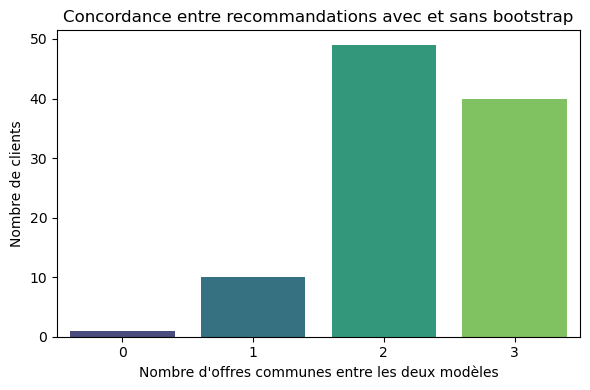

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap du nombre d'offres communes (0, 1, 2, 3)
match_counts = comparison['n_common_offers'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=match_counts.index, y=match_counts.values, palette="viridis")
plt.xlabel("Nomber of commun offers between bootstrap and without bootstrap")
plt.ylabel("Nomber of clients")
plt.title("Concordance between bootstrap and without bootstrap")
plt.tight_layout()
plt.show()

The barplot above shows the number of common offers between the two models (out of 3 possible) for each customer-month.

| Common Offers | Interpretation                    |
|---------------|------------------------------------|
| 0             | Total disagreement between models  |
| 1             | Partial match, low consistency     |
| 2             | High overlap, some reordering      |
| 3             | Full agreement, strong stability   |

**Observation**:  
- Most customer predictions have **2 or 3 common offers**, confirming that the recommendations are **mostly consistent**.
- Only **a few cases (1 or 0)** show model disagreement — likely due to noise or borderline similarity scores.

This supports the idea that the bootstrap-enhanced model is robust and not introducing erratic recommendations.


### **Top-1 Offer Frequency by Model**

<Figure size 800x500 with 0 Axes>

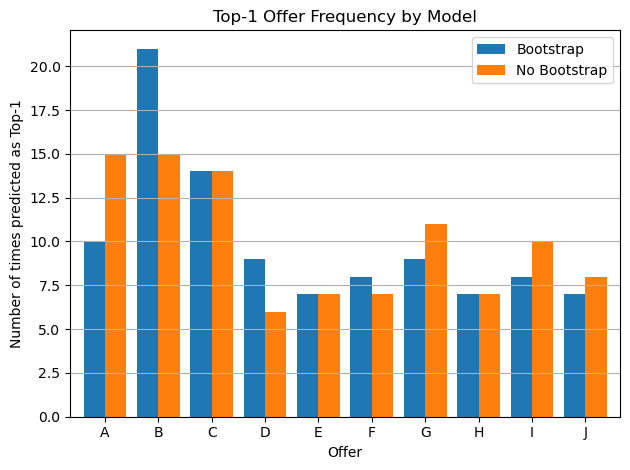

In [131]:
# Compter la fréquence des offres en position 1 dans les deux modèles
from collections import Counter

# Compter pour le modèle bootstrap
top1_bootstrap = comparison['offer_1_recommendation_bootstrap'].value_counts().sort_index()

# Compter pour le modèle sans bootstrap
top1_nobootstrap = comparison['offers_1_offer_recommendation_without_bootstap'].value_counts().sort_index()

# Fusionner pour comparer
offer_freq_df = pd.DataFrame({
    'Bootstrap': top1_bootstrap,
    'No Bootstrap': top1_nobootstrap
}).fillna(0)

# Afficher un barplot comparatif
plt.figure(figsize=(8, 5))
offer_freq_df.plot(kind='bar', width=0.8)
plt.title("Top-1 Offer Frequency by Model")
plt.xlabel("Offer")
plt.ylabel("Number of times predicted as Top-1")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


This barplot compares how often each offer (A–J) was recommended in **top-1 position** by both the bootstrap and no-bootstrap models.

**Observations:**
- Offer **B** appears most frequently as top-1 in both models, with a stronger preference in the **bootstrap version**.
- The **bootstrap model** tends to distribute more top-1 predictions across offers A–D.
- The **no-bootstrap model** tends to elevate offers **G, I, and J** slightly more than the bootstrap version.
- Some offers (like E and H) are equally predicted across both models → stable regardless of sampling.

**What this shows:**
- This visualization reveals the **distribution bias** of each model — some models may overfit toward certain offers.
- Bootstrap appears to reduce overconfidence in tail offers by increasing top-1 diversity slightly.

This kind of insight helps ensure that recommendations are **balanced and fair** across the offer set.
